In [2]:
from pathlib import Path
import pandas as pd

data_dir = Path("../DataSets")

print(f"Looking inside: {data_dir.resolve()}")
print()

if not data_dir.exists():
    print(f"Folder not found: {data_dir}")
else:
    files = sorted([p for p in data_dir.iterdir() if p.is_file()])
    print(f"Found {len(files)} file(s):")
    print()

    for path in files:
        print(f"File: {path.name}")
        print(f"Size: {path.stat().st_size} bytes")

        suffix = path.suffix.lower()

        try:
            if suffix == ".csv":
                df = pd.read_csv(path)
            elif suffix in {".xls", ".xlsx"}:
                df = pd.read_excel(path)
            elif suffix == ".json":
                df = pd.read_json(path)
            elif suffix in {".parquet", ".pq"}:
                df = pd.read_parquet(path)
            elif suffix == ".tsv" or suffix == ".txt":
                df = pd.read_csv(path, sep="\t")
            else:
                print("Unsupported format for automatic inspection")
                print()
                continue

            print(f"Rows: {len(df)}")
            print(f"Columns: {len(df.columns)}")
            print("Column names:")
            print(list(df.columns))
            print("First few rows:")
            print(df.head())
            print("-" * 80)
            print()

        except Exception as e:
            print(f"Could not read file: {e}")
            print("-" * 80)
            print()

Looking inside: E:\PROJECTS\CHESS_PUzZLeS_RLG\DataSets

Found 1 file(s):

File: lichess_db_puzzle.csv
Size: 1108157621 bytes
Rows: 6014381
Columns: 10
Column names:
['PuzzleId', 'FEN', 'Moves', 'Rating', 'RatingDeviation', 'Popularity', 'NbPlays', 'Themes', 'GameUrl', 'OpeningTags']
First few rows:
  PuzzleId                                                FEN  \
0    00008  r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...   
1    0000D  5rk1/1p3ppp/pq3b2/8/8/1P1Q1N2/P4PPP/3R2K1 w - ...   
2    0008Q       8/4R3/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 w - - 1 64   
3    0009B  r2qr1k1/b1p2ppp/pp4n1/P1P1p3/4P1n1/B2P2Pb/3NBP...   
4    000Pw  6k1/5p1p/4p3/4q3/3nN3/2Q3P1/PP3P1P/6K1 w - - 2 37   

                           Moves  Rating  RatingDeviation  Popularity  \
0  f2g3 e6e7 b2b1 b3c1 b1c1 h6c1    1862               76          95   
1            d3d6 f8d8 d6d8 f6d8    1579               73          96   
2            e7f7 f5e5 e2f1 e5e6    1385               80          92   
3            b6c5

In [3]:
df.head()

,PuzzleId,FEN,Moves,Rating,RatingDeviation,Popularity,NbPlays,Themes,GameUrl,OpeningTags
0,00008,r6k/pp2r2p/4Rp1Q/3p4/8/1N1P2R1/PqP2bPP/7K b - ...,f2g3 e6e7 b2b1 b3c1 b1c1 h6c1,1862,76,95,9697,crushing hangingPiece long middlegame,https://lichess.org/787zsVup/black#48,NaN
1,0000D,5rk1/1p3ppp/pq3b2/8/8/1P1Q1N2/P4PPP/3R2K1 w - ...,d3d6 f8d8 d6d8 f6d8,1579,73,96,36672,advantage endgame short,https://lichess.org/F8M8OS71#53,NaN
2,0008Q,8/4R3/1p2P3/p4r2/P6p/1P3Pk1/4K3/8 w - - 1 64,e7f7 f5e5 e2f1 e5e6,1385,80,92,765,advantage endgame rookEndgame short,https://lichess.org/MQSyb3KW#127,NaN
3,0009B,r2qr1k1/b1p2ppp/pp4n1/P1P1p3/4P1n1/B2P2Pb/3NBP...,b6c5 e2g4 h3g4 d1g4,1084,74,88,606,advantage middlegame short,https://lichess.org/4MWQCxQ6/black#32,Kings_Pawn_Game Kings_Pawn_Game_Leonardis_Vari...
4,000Pw,6k1/5p1p/4p3/4q3/3nN3/2Q3P1/PP3P1P/6K1 w - - 2 37,e4d2 d4e2 g1f1 e2c3,1550,75,92,626,crushing endgame fork short,https://lichess.org/au2lCK5o#73,NaN


In [8]:
df["OpeningTags"].isna().sum()
df["OpeningTags"].value_counts()

OpeningTags
Italian_Game Italian_Game_Two_Knights_Defense                        17755
Caro-Kann_Defense Caro-Kann_Defense_Other_variations                 17503
Indian_Defense Indian_Defense_Other_variations                       16654
Queens_Pawn_Game Queens_Pawn_Game_Accelerated_London_System          16290
Queens_Pawn_Game Queens_Pawn_Game_Other_variations                   14201
                                                                     ...  
Kings_Gambit_Accepted Kings_Gambit_Accepted_Dodo_Variation               1
Benko_Gambit Benko_Gambit_Nd2_Variation                                  1
Hungarian_Opening Hungarian_Opening_Winterberg_Gambit                    1
Queens_Gambit_Declined Queens_Gambit_Declined_Semmering_Variation        1
Scotch_Game Scotch_Game_Hanneken_Variation                               1
Name: count, Length: 1430, dtype: int64

In [22]:
print("Min rating:", df["Rating"].min())
print("Max rating:", df["Rating"].max())


Min rating: 399
Max rating: 3327


Below 800: 583696 puzzles (9.71%)
801-1000: 752541 puzzles (12.51%)
1001-1200: 870774 puzzles (14.48%)
1201-1500: 1089246 puzzles (18.11%)
1501-1800: 1000305 puzzles (16.63%)
1801-2000: 564419 puzzles (9.38%)
2001-2100: 246437 puzzles (4.10%)
2101-2200: 215982 puzzles (3.59%)
2201-2300: 191526 puzzles (3.18%)
2301-2350: 88832 puzzles (1.48%)
2351-2400: 65604 puzzles (1.09%)
Above 2400: 345019 puzzles (5.74%)


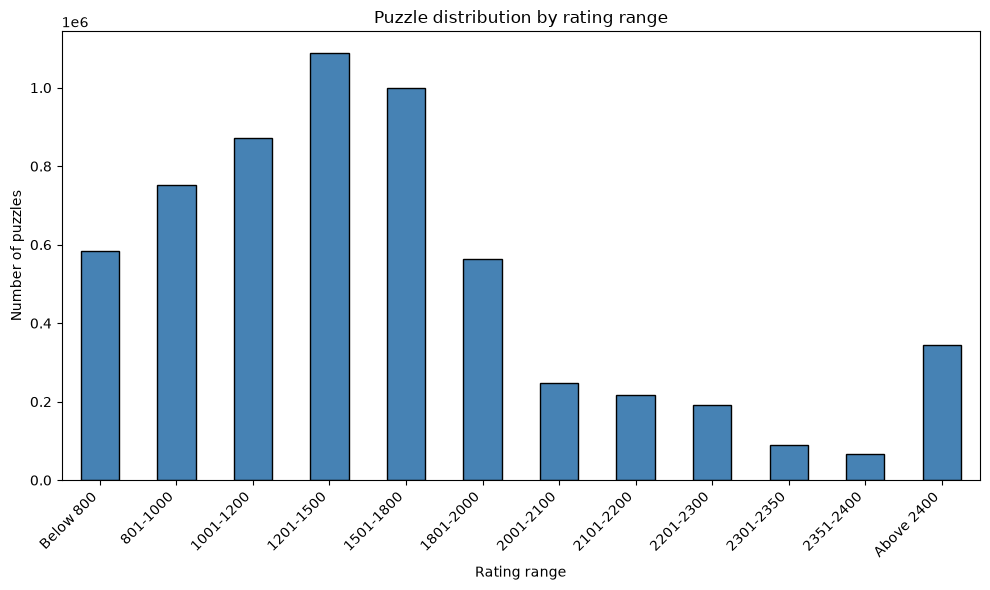

In [24]:
import matplotlib.pyplot as plt

# Define the rating ranges
bins = [-1, 800, 1000, 1200, 1500, 1800, 2000, 2100, 2200, 2300, 2350, 2400, float("inf")]
labels = [
    "Below 800",
    "801-1000",
    "1001-1200",
    "1201-1500",
    "1501-1800",
    "1801-2000",
    "2001-2100",
    "2101-2200",
    "2201-2300",
    "2301-2350",
    "2351-2400",
    "Above 2400"
]

# Assign each puzzle to a rating bucket
rating_bucket = pd.cut(df["Rating"], bins=bins, labels=labels, include_lowest=True)

# Count puzzles in each bucket (keep the desired order)
counts = rating_bucket.value_counts().reindex(labels)

for label, count in counts.items():
    percentage = (count / len(df)) * 100
    print(f"{label}: {count} puzzles ({percentage:.2f}%)")

# Plot
plt.figure(figsize=(10, 6))
counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Puzzle distribution by rating range")
plt.xlabel("Rating range")
plt.ylabel("Number of puzzles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Below 10: 39503 puzzles (0.66%)
11-20: 10755 puzzles (0.18%)
21-30: 16541 puzzles (0.28%)
31-40: 49359 puzzles (0.82%)
41-50: 81217 puzzles (1.35%)
51-60: 125851 puzzles (2.09%)
61-70: 234744 puzzles (3.90%)
71-80: 581140 puzzles (9.66%)
81-90: 1997500 puzzles (33.21%)
91-100: 2877716 puzzles (47.85%)


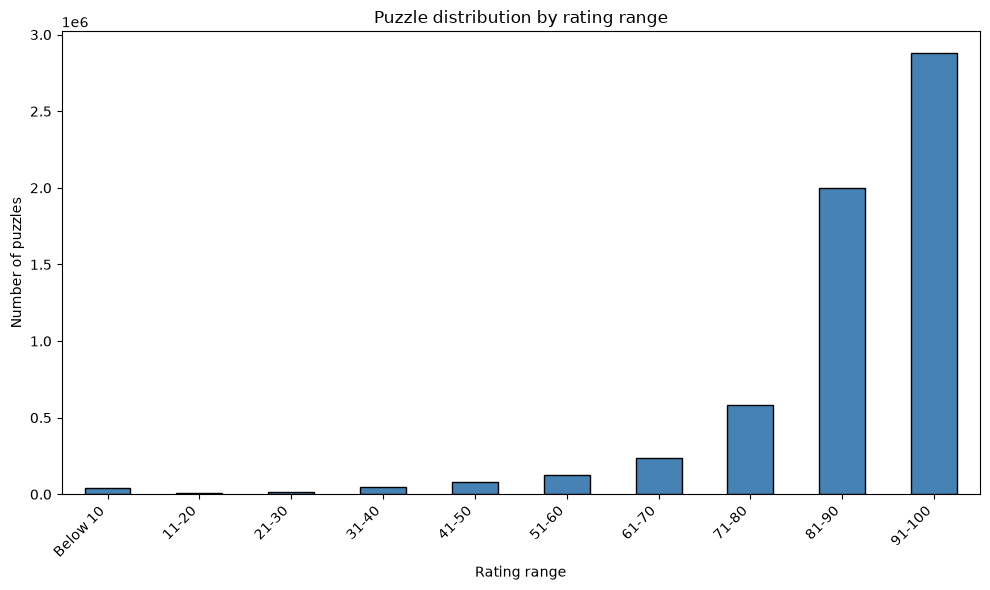

: 

In [ ]:
import matplotlib.pyplot as plt

# Define the rating ranges
bins = [-1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, float("inf")]
labels = [
    "Below 10",
    "11-20",
    "21-30",
    "31-40",
    "41-50",
    "51-60",
    "61-70",
    "71-80",
    "81-90",
    "91-100"
]

# Assign each puzzle to a rating bucket
popularity_bucket = pd.cut(
    df["Popularity"],
    bins=bins[:-1],   # 11 edges -> matches the 10 labels
    labels=labels,
    include_lowest=True
)

# Count puzzles in each bucket (keep the desired order)
counts = popularity_bucket.value_counts().reindex(labels)

for label, count in counts.items():
    percentage = (count / len(df)) * 100
    print(f"{label}: {count} puzzles ({percentage:.2f}%)")

# Plot
plt.figure(figsize=(10, 6))
counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Puzzle distribution by rating range")
plt.xlabel("Rating range")
plt.ylabel("Number of puzzles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()